# Intraday Price Pattern Analysis
**Research question:** Does forecast accuracy vary systematically across the day?
Are some time-of-day periods easier to forecast than others?

# Step 1 - Imports

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

print("Imports OK")

Imports OK


# Step 2 - Configuration

In [13]:
split_dir  = Path("../data/split")
output_dir = Path("../data/results")
plot_dir   = Path("../data/results/plots")
plot_dir.mkdir(parents=True, exist_ok=True)

nintervals = 96   # quarter-hours per day

# time-of-day periods (quarter-hourly intervals)
# interval 0 = 00:00, interval 95 = 23:45
periods = {
    "Night (00:00-06:00)"    : (0,  24),
    "Morning (06:00-12:00)"  : (24, 48),
    "Afternoon (12:00-18:00)": (48, 72),
    "Evening (18:00-24:00)"  : (72, 96),
}

# x-axis ticks: every 3 hours = 12 quarter-hourly intervals
time_labels = [f"{h:02d}:00" for h in range(0, 24, 3)]
time_ticks  = [i * 12 for i in range(8)]

# colours consistent with model notebooks
colors_models  = {"LEAR": "green", "XGBoost": "tomato", "LSTM": "purple"}
colors_periods = ["#e8f4f8", "#fef9e7", "#e8f8e8", "#fde8e8"]

print("Time periods:")
for p, (start, end) in periods.items():
    print(f"  {p}: intervals {start}\u2013{end - 1}")

Time periods:
  Night (00:00-06:00): intervals 0–23
  Morning (06:00-12:00): intervals 24–47
  Afternoon (12:00-18:00): intervals 48–71
  Evening (18:00-24:00): intervals 72–95


# Step 3 - Load Results

In [14]:
with open(output_dir / "LEAR.pkl", "rb") as f:
    lear_dict = pickle.load(f)[0]

with open(output_dir / "XGBoost.pkl", "rb") as f:
    xgb_dict = pickle.load(f)[0]

with open(output_dir / "LSTM.pkl", "rb") as f:
    lstm_dict = pickle.load(f)[0]

# ground-truth prices — same for all models, shape (44, 96)
y_test = xgb_dict["y_test"]

# predictions, shape (44, 96)
y_pred_lear = lear_dict["prediction"]
y_pred_xgb  = xgb_dict["prediction"]
y_pred_lstm = lstm_dict["prediction"]

test_days = xgb_dict["test_days"]

print(f"y_test shape : {y_test.shape}")
print(f"Test period  : {test_days[0]} to {test_days[-1]}")
print(f"\nOverall MAE from model notebooks (reference):")
print(f"  LEAR    : {lear_dict['mae']:.4f} EUR/MWh")
print(f"  XGBoost : {xgb_dict['mae']:.4f} EUR/MWh")
print(f"  LSTM    : {lstm_dict['mae']:.4f} EUR/MWh")

y_test shape : (44, 96)
Test period  : 2026-01-16 to 2026-02-28

Overall MAE from model notebooks (reference):
  LEAR    : 12.0580 EUR/MWh
  XGBoost : 11.5527 EUR/MWh
  LSTM    : 20.6375 EUR/MWh


# Step 4 - MAE by Time of Day
MAE is computed per quarter-hourly interval and aggregated by time-of-day period. Overall MAE is computed directly from the errors here to ensure consistency with the per-period figures.

In [15]:
models = {
    "LEAR"    : y_pred_lear,
    "XGBoost" : y_pred_xgb,
    "LSTM"    : y_pred_lstm,
}

mae_per_interval = {}   # {model: array (96,)}
mae_per_period   = {}   # {model: {period: float}}
mae_overall      = {}   # {model: float} — computed fresh, not from pkl

for model_name, y_pred in models.items():
    errors = np.abs(y_test - y_pred)                     # (44, 96)
    mae_per_interval[model_name] = errors.mean(axis=0)   # (96,)
    mae_overall[model_name]      = float(errors.mean())  # scalar
    mae_per_period[model_name]   = {}
    for period, (start, end) in periods.items():
        mae_per_period[model_name][period] = float(errors[:, start:end].mean())

print("MAE by time-of-day period (EUR/MWh):")
print(f"  {'Period':<30} {'LEAR':>10} {'XGBoost':>10} {'LSTM':>10}")
print("  " + "-" * 62)
for period in periods:
    ml = mae_per_period["LEAR"][period]
    mx = mae_per_period["XGBoost"][period]
    mm = mae_per_period["LSTM"][period]
    print(f"  {period:<30} {ml:>10.4f} {mx:>10.4f} {mm:>10.4f}")
print("  " + "-" * 62)
print(f"  {'Overall':<30} {mae_overall['LEAR']:>10.4f} "
      f"{mae_overall['XGBoost']:>10.4f} {mae_overall['LSTM']:>10.4f}")

MAE by time-of-day period (EUR/MWh):
  Period                               LEAR    XGBoost       LSTM
  --------------------------------------------------------------
  Night (00:00-06:00)                9.5984     6.6858    15.3446
  Morning (06:00-12:00)             13.0123    13.6668    23.4670
  Afternoon (12:00-18:00)           13.5177    14.7850    27.6729
  Evening (18:00-24:00)             12.1037    11.0730    16.0657
  --------------------------------------------------------------
  Overall                           12.0580    11.5527    20.6375


# Step 5 - MAE per Interval (Line Plot)

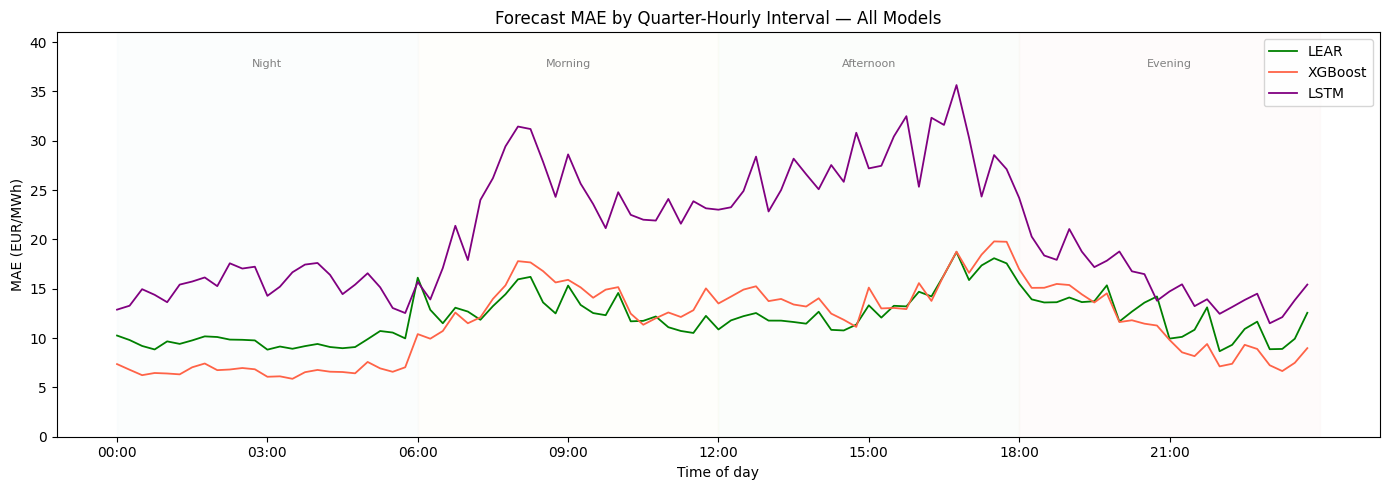

Plot saved


In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

for model_name, mae_arr in mae_per_interval.items():
    ax.plot(mae_arr, label=model_name, linewidth=1.3,
            color=colors_models[model_name])

# set y-limit before adding text so placement is stable
max_mae = max(arr.max() for arr in mae_per_interval.values())
ax.set_ylim(0, max_mae * 1.15)

for (period, (start, end)), color in zip(periods.items(), colors_periods):
    ax.axvspan(start, end, alpha=0.15, color=color)
    ax.text((start + end) / 2, max_mae * 1.05,
            period.split()[0], ha="center", fontsize=8, color="gray")

ax.set_xticks(time_ticks)
ax.set_xticklabels(time_labels)
ax.set_title("Forecast MAE by Quarter-Hourly Interval \u2014 All Models")
ax.set_xlabel("Time of day")
ax.set_ylabel("MAE (EUR/MWh)")
ax.legend()
plt.tight_layout()
plt.savefig(plot_dir / "mae_per_interval.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved")

# Step 6 - Save Results

In [17]:
analysis_dict = {
    "mae_per_interval" : mae_per_interval,
    "mae_per_period"   : mae_per_period,
    "mae_overall"      : mae_overall,
    "periods"          : periods,
    "y_test"           : y_test,      # (44, 96) EUR/MWh
    "test_days"        : test_days,
}

with open(output_dir / "analysis.pkl", "wb") as f:
    pickle.dump(analysis_dict, f)

print(f"Saved: {output_dir / 'analysis.pkl'}")
print(f"Plot saved to: {plot_dir / 'mae_per_interval.png'}")
print("\nanalysis.ipynb complete")

Saved: ..\data\results\analysis.pkl
Plot saved to: ..\data\results\plots\mae_per_interval.png

analysis.ipynb complete
